In [ ]:
#-- Import general libraries
import numpy as np 
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


This code shows how one can create simple forward and inverse models using the NNPDEs method. 

For the forward model, we want to find the second order derivative of $f(x)$, which is given by:
$$ f(x) = sin(x) , \quad x \in [0, 2\pi] $$


We use a second order discretisation in space: $$  \frac{d^2f}{dx^2}\Bigr|_i= \frac{f_{i+1} - 2f_{i} + f_{i-1}}{\Delta x^2} $$

This is akin to applying a kernel of $[1, -2, 1]$ to $f(x)$, then dividing by $\Delta x^2$. 

Convolution will remove the halo nodes at $x = 0$ and $x = 2\pi$, which means we need to append the boundary conditions: $$ \frac{d^2f}{dx^2}\Bigr|_{x=0}= \frac{d^2f}{dx^2}\Bigr|_{x=2\pi} = 0$$



In [ ]:
# Space discretisation 
Nx = 21  # no. of space intervals 
xa = 0
xb = 2*np.pi
x = np.linspace(xa, xb, Nx) # create x array
dx = (xb-xa)/(Nx-1)


In [ ]:
class SinxConv(nn.Module):
    def __init__(self, Nx, filter_weight): #filter_weight
        super(SinxConv, self).__init__()

        # Specify the size of the input (batch_size, number of input channels, length of input tensor)
        input_size = (1, 1, Nx)  
        batch_size, in_channels, width = input_size

        # Specify the size of the filter/kernel
        kernel_size = filter_weight.shape[2]

        # Create a Conv1d layer with the specified weight, input size, and padding
        self.conv_layer = nn.Conv1d(in_channels, out_channels=1,kernel_size=kernel_size, padding='valid', bias=False)
        self.conv_layer.weight.data = filter_weight

    def forward(self, previous):

        future = self.conv_layer(previous) # previous(1,1,Nx); future(1,1,Nx-2)
        return future

In [ ]:
def forward(mymodel_time_march,fx,dx):

    # Transform into 3D tensor
    fx_tensor = fx.view(1, 1, Nx)
    output = mymodel_time_march(fx_tensor)/dx**2

    #Append BCs 
    output = torch.cat((torch.tensor([0.]), output[0,0,:], torch.tensor([0.])), 0)

    return output

In [ ]:
# Convert NumPy arrays to PyTorch tensors with float type
x_tensor = torch.tensor(np.array(x), dtype=torch.float64)

# filter corresponding to the above kernel. r will be calculated and applied in the solver in the next section
filter = torch.tensor([1, -2, 1], dtype=torch.float64)

# resize filter for PyTorch
# filter_weight(num_kernels/output channels, kernel_height, kernel_width)
filter_weight = filter.view(1, 1, filter.shape[0])

# Create instance of convolution and use it as a function to apply convolution
mymodel_time_march = SinxConv(Nx,filter_weight)


Text(0, 0.5, '$\\frac{d^2f}{dx^2}$')

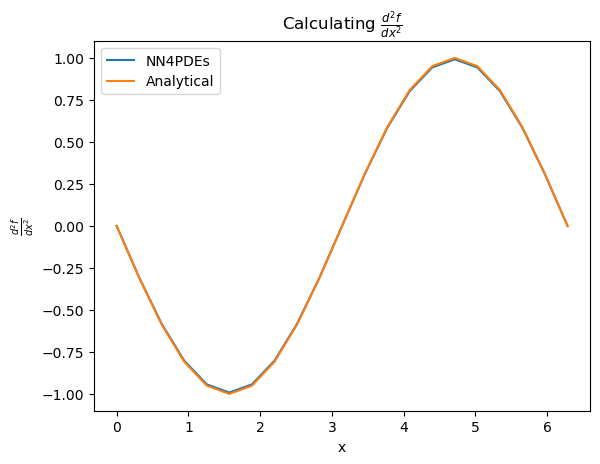

In [ ]:
# Create fx 
fx = torch.sin(x_tensor)

# Calculate second order derivative of fx using NNPDEs
output = forward(mymodel_time_march,fx,dx)

# Calculate second order derivative of fx using analytical solution
output_analytical = -torch.sin(x_tensor)
plt.plot(x,output.detach().numpy(), label='NN4PDEs')
plt.plot(x,output_analytical.detach().numpy(), label='Analytical')
plt.legend()
plt.title(r'Calculating $\frac{d^2f}{dx^2}$')
plt.xlabel('x')
plt.ylabel(r'$\frac{d^2f}{dx^2}$')

For the inverse model, we want to find the value of $C$ using assimilation: $$ \frac{d^2f}{dx^2}\Bigr|_i = C \times \frac{f_{i+1} - 2f_{i} + f_{i-1}}{\Delta x^2}, \quad C \approx 1 $$

We will be assimilating to $-sin(x)$, the analytical solution of $ \frac{d^2f}{dx^2} $

In [ ]:
#Create a forward function that allows C to be optimised
def forward(C,mymodel_time_march,fx,dx):

    C.retain_grad()

    # Transform into 3D tensor
    fx_tensor = fx.view(1, 1, Nx)
    output = mymodel_time_march(fx_tensor)/dx**2

    #Append BCs 
    output = C*torch.cat((torch.tensor([0.]), output[0,0,:], torch.tensor([0.])), 0)

    return output

In [ ]:
mse_loss = nn.MSELoss()

target = -torch.sin(x_tensor)
fx = torch.sin(x_tensor)


# Use Adam optimizer
iterations = 300
# Store the history of C values and losses for plotting
c_values = np.zeros(iterations)
losses = np.zeros(iterations)

#Initial guess for C
C = torch.tensor([0.5],requires_grad=True)
optimizer = torch.optim.Adam([C], lr=0.01)
for n in range(iterations):   
    optimizer.zero_grad()
    # Forward pass through the model
    output = forward(C,mymodel_time_march,fx,dx)

    # Compute the loss
    loss = mse_loss(output, target)
    
    # Backward pass to calculate gradients
    loss.backward(retain_graph=True)
    losses[n]=loss.item()
    c_values[n]=C.item()

    if n % 50 == 0:
        print('Iteration:', n)
        print('C:',C.item())
        print('Loss:',loss.item())

    # optimize C
    optimizer.step()

Iteration: 0
C: 0.5
Loss: 0.12100744302450635
Iteration: 50
C: 0.9118962287902832
Loss: 0.00435018136326111
Iteration: 100
C: 1.0116392374038696
Loss: 5.331812789115958e-06
Iteration: 150
C: 1.0082330703735352
Loss: 4.901037691623742e-10
Iteration: 200
C: 1.0082676410675049
Loss: 2.3170749453917368e-12
Iteration: 250
C: 1.008264422416687
Loss: 4.633229424045782e-13


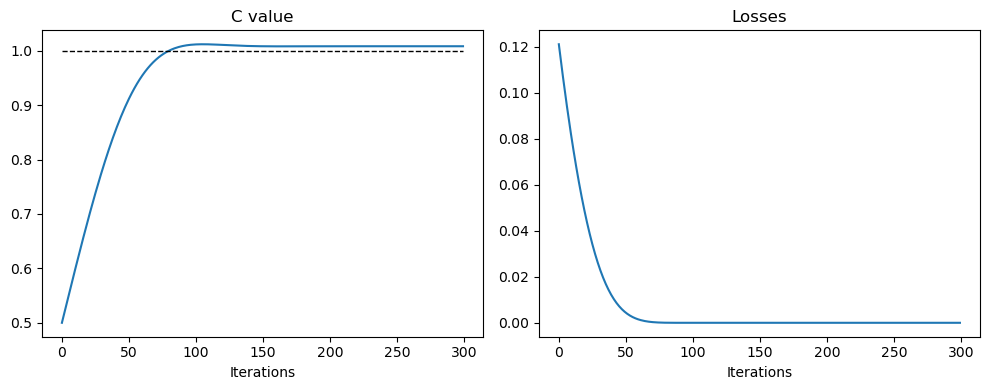

In [ ]:
fig, axs = plt.subplots(1, 2,figsize=(10,4))
axs[0].plot(range(iterations),c_values)
axs[0].plot(range(iterations),1*np.ones(iterations),'k--',linewidth = 1,label='True value')
axs[0].set_title('C value')
axs[0].set_xlabel('Iterations')

axs[1].plot(range(iterations),losses)
axs[1].set_title('Losses')
axs[1].set_xlabel('Iterations')
fig.tight_layout()